### Intro to PyTorch

In [49]:
import torch
import numpy as np
import time
from torch.utils.data import TensorDataset, DataLoader
import torchvision 
import torchvision.transforms as transforms
from torch import nn

##### What is PyTorch 

Python-based scientific computing package targeted at two sets of audiences 
- relpacement for NumPy to use the power of GPUs
- deep learning research platform that provides maximum flexibility and speed

##### PyTorch Tensors 
- generalize vectors/matrices, like NumPy's ndarrays

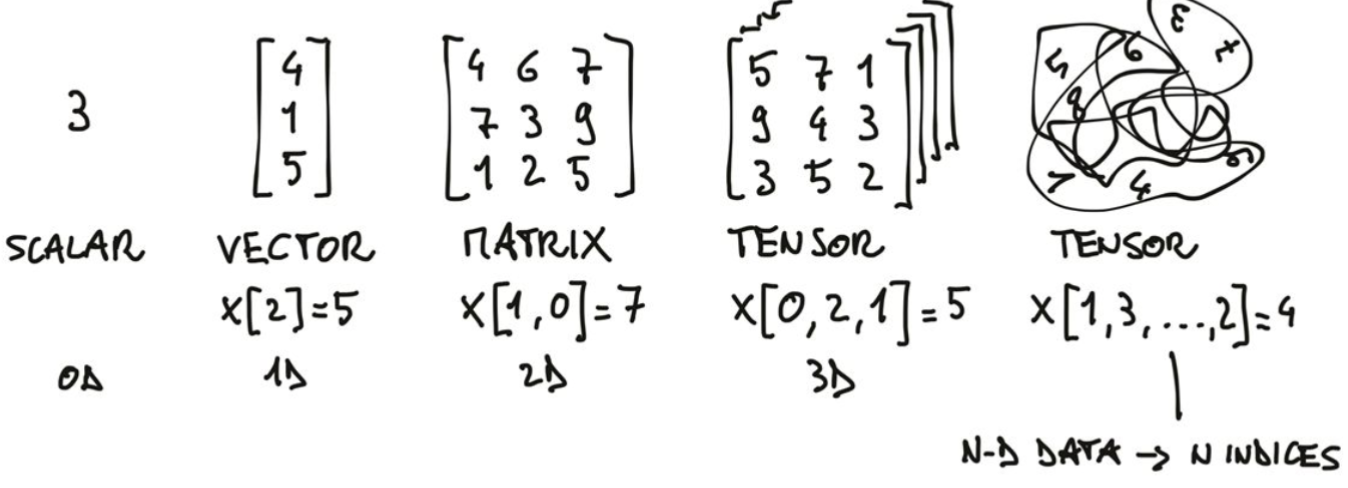

##### Properties of Tensors
- generatlization of vectors and matrices 
- In PyTorch, they are a multi-dimensional matrix containing elements

In [50]:
t = torch.tensor([[1., -1.], [1., -1.]])
print(t)

tensor([[ 1., -1.],
        [ 1., -1.]])


In [51]:
print("data type:", t.dtype)
print("shape:", t.shape)
print("device:", t.device)

data type: torch.float32
shape: torch.Size([2, 2])
device: cpu


##### Creating Tensors 


In [52]:
x = torch.empty(5, 3) # uninitialized
print(x)

tensor([[ 0.0000,  0.0000,  0.1629],
        [-1.2576, -0.6214,  0.4726],
        [-0.1139,  0.0635,  0.1906],
        [ 0.0000,  0.3004,  0.1677],
        [ 0.0307,  0.2083,  0.0687]])


In [53]:
x = torch.rand(5, 3) # randomly initialized between 0 and 1
print(x)

tensor([[0.6790, 0.3736, 0.0163],
        [0.6724, 0.3750, 0.2032],
        [0.7910, 0.9438, 0.4600],
        [0.7272, 0.0326, 0.5398],
        [0.2900, 0.1409, 0.6107]])


In [54]:
x = torch.zeros(5, 3, dtype = torch.long) # initialized to all zeros; long integer data type
print(x)

tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]])


In [55]:
x = torch.tensor([5.5, 3]) # create a tensor directly from data
print(x)

tensor([5.5000, 3.0000])


##### Create a tensor based on an existing tensor

In [56]:
x = x.new_ones(5, 3, dtype = torch.double) # new_* methods take in sizes
print(x)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)


In [57]:
x = torch.randn_like(x, dtype = torch.float)# override dtype!
print(x)

tensor([[ 0.3809, -0.2686,  1.0425],
        [-0.2289, -2.0337, -0.1426],
        [ 0.3368, -0.4846,  0.2096],
        [ 1.8886,  0.3796,  1.7896],
        [ 0.1109, -1.2093, -0.4499]])


##### Operations

In [58]:
y = torch.rand(5, 3)
print(x + y) # addition syntax 1 

print(torch.add(x, y)) # addition syntax 2

tensor([[ 1.1238,  0.5090,  2.0286],
        [-0.0901, -1.8054,  0.0866],
        [ 1.2280,  0.1190,  0.5872],
        [ 2.2511,  1.2427,  2.1942],
        [ 0.6895, -1.0399, -0.0323]])
tensor([[ 1.1238,  0.5090,  2.0286],
        [-0.0901, -1.8054,  0.0866],
        [ 1.2280,  0.1190,  0.5872],
        [ 2.2511,  1.2427,  2.1942],
        [ 0.6895, -1.0399, -0.0323]])


In [59]:
result = torch.empty(5, 3)
torch.add(x, y, out = result)

tensor([[ 1.1238,  0.5090,  2.0286],
        [-0.0901, -1.8054,  0.0866],
        [ 1.2280,  0.1190,  0.5872],
        [ 2.2511,  1.2427,  2.1942],
        [ 0.6895, -1.0399, -0.0323]])

##### Tensor Operations with 'dim'

In [60]:
x = torch.ones([2,3,4])
print("x:", x)
print(" sum:", x.sum())
print(" shape:", x.sum().shape)
print(" sum along dim 1:", x.sum(dim=1))

x: tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])
 sum: tensor(24.)
 shape: torch.Size([])
 sum along dim 1: tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.]])


##### Resizing

In [61]:
x = torch.randn(4, 4) 
y = x.view(16) # view() is used to reshape the tensor without changing its data.
z = x.view(-1, 8) # -1 means the size of that dimension is inferred from the other dimensions
print("x:", x)
print("y:", y)
print("z:", z)

x: tensor([[-0.0483, -1.1389, -0.1832, -0.1317],
        [ 0.1489,  0.0539,  0.3215,  1.6496],
        [ 0.5030,  1.2373,  1.5558, -0.3078],
        [-0.1771, -0.3850, -1.2221,  0.8767]])
y: tensor([-0.0483, -1.1389, -0.1832, -0.1317,  0.1489,  0.0539,  0.3215,  1.6496,
         0.5030,  1.2373,  1.5558, -0.3078, -0.1771, -0.3850, -1.2221,  0.8767])
z: tensor([[-0.0483, -1.1389, -0.1832, -0.1317,  0.1489,  0.0539,  0.3215,  1.6496],
        [ 0.5030,  1.2373,  1.5558, -0.3078, -0.1771, -0.3850, -1.2221,  0.8767]])


In [62]:
x = torch.randn(1)
print(x)
print(x.item()) # item() is used to get the value of a single element tensor as a standard Python number.

tensor([1.1919])
1.191949486732483


##### Converting a Torch Tensor to and from a NumPy Array

In [63]:
a = torch.ones(5)
print(a)

b = a.numpy() # Convert a PyTorch tensor to a NumPy array
print(b)

a.add_(1) # In-place addition, modifies the original tensor
print(a)
print(b) # The NumPy array reflects the change since it shares the same memory with the tensor

tensor([1., 1., 1., 1., 1.])
[1. 1. 1. 1. 1.]
tensor([2., 2., 2., 2., 2.])
[2. 2. 2. 2. 2.]


In [64]:
a = np.ones(5) 
b = torch.from_numpy(a) # Convert a NumPy array to a PyTorch tensor
np.add(a, 1, out=a) # In-place addition on the NumPy array
print(a)
print(b) # The PyTorch tensor reflects the change since it shares the same memory with the NumPy array

[2. 2. 2. 2. 2.]
tensor([2., 2., 2., 2., 2.], dtype=torch.float64)


##### CUDA Tensors

CUDA is a parallel computing platform and application programming interface (API) model created by Nvidia. It allows software developers to use a CUDA-enabled graphics processing unit (GPU) for general purpose processing, an approach known as GPGPU (General-Purpose computing on Graphics Processing Units).

In [65]:
# Move tensors to the GPU if available
if torch.cuda.is_available():
    device = torch.device("cuda")          # a CUDA device object
    y = torch.ones_like(x, device=device)  # directly create a tensor on GPU
    x = x.to(device)                       # or just use strings ``.to("cuda")``
    z = x + y
    print(z)
    print(z.to("cpu", torch.double))       # ``.to`` can also change dtype together!


In [66]:
# x_cpu = torch.randn(120000, 10000) 
# y_cpu = torch.randn(10000, 1)

# x_gpu = x_cpu.to("cuda")
# y_gpu = y_cpu.to("cuda")

# start = time.time()
# z_cpu = torch.mm(x_cpu, y_cpu)
# print("CPU time:", time.time() - start)

# start = time.time()
# z_gpu = torch.mm(x_gpu, y_gpu)
# print("GPU time:", time.time() - start)

##### Automatic Differentiation

In [67]:
x = torch.ones(2, 2, requires_grad=True)
print(x) 

tensor([[1., 1.],
        [1., 1.]], requires_grad=True)


In [68]:
y = x + 2 
print(y)
# grad_fn attribute of a tensor references a Function that has created the tensor (except for tensors created by the user - their grad_fn is None).
print(y.grad_fn)  

tensor([[3., 3.],
        [3., 3.]], grad_fn=<AddBackward0>)


In [69]:
z = y * y * 3 
out = z.mean() 
print(z, out)

tensor([[27., 27.],
        [27., 27.]], grad_fn=<MulBackward0>) tensor(27., grad_fn=<MeanBackward0>)


We have

$$
\mathbf{x} \in \mathbb{R}^{2 \times 2}, \qquad \mathbf{x} = \mathbf{1}
$$

Then

$$
\mathbf{y} = \mathbf{x} + 2
$$

$$
\mathbf{z} = 3\mathbf{y}^2 = 3(\mathbf{x}+2)^2
$$

and

$$
\text{out} = \frac{1}{4}\sum_{i=1}^{4} z_i
= \frac{1}{4}\sum_{i=1}^{4} 3(x_i+2)^2
$$

For each element,

$$
\frac{\partial\,\text{out}}{\partial x_i}
= \frac{1}{4}\cdot 3 \cdot 2(x_i+2)
= \frac{3}{2}(x_i+2)
$$

At $x_i = 1$,

$$
\frac{\partial\,\text{out}}{\partial x_i}
= \frac{3}{2}(1+2)
= \frac{9}{2}
= 4.5
$$

So `x.grad` contains `4.5` for every element.

In [70]:
# backward computes the gradient of out with respect to all Tensors with requires_grad=True.
out.backward()

# gradient is accumulated into .grad attribute
print(x.grad)

tensor([[4.5000, 4.5000],
        [4.5000, 4.5000]])


##### More Gradients 

In [71]:
x = torch.randn(3, requires_grad=True)

y = x * 2 
while y.data.norm() < 100: 
    y = y * 2
    print(y)

tensor([ 1.3294, -4.9675,  7.8032], grad_fn=<MulBackward0>)
tensor([ 2.6588, -9.9350, 15.6063], grad_fn=<MulBackward0>)
tensor([  5.3176, -19.8699,  31.2127], grad_fn=<MulBackward0>)
tensor([ 10.6351, -39.7399,  62.4254], grad_fn=<MulBackward0>)
tensor([ 21.2703, -79.4798, 124.8508], grad_fn=<MulBackward0>)


In [72]:
gradients = torch.tensor([0.1, 1.0, 0.0001], dtype=torch.float)
# Now gradients is d(out)/dy, we can compute and print out d(out)/dx = d(out)/dy * dy/dx
y.backward(gradients)

print(x.grad)

tensor([6.4000e+00, 6.4000e+01, 6.4000e-03])


##### We don't always need gradients
- can stop autograd from tracking history on Tensors with `.requires_grad=True` by wrapping the code block in `with torch.no_grad()`:

In [73]:
print(x.requires_grad) # True
print((x ** 2).requires_grad) # True

with torch.no_grad():
    print((x ** 2).requires_grad) # False

True
True
False


##### (Stochastic) Gradient Descent 

In [74]:
# Iterative gradient based solvesr 

def f(x): 
    return -x**2 + 10 * x * x.log() 

x = torch.ones(1, requires_grad=True)
y = f(x) 
y.backward() # compute gradients d(y)/dx
print(x.grad)

tensor([8.])


Text(0.5, 1.0, 'Plot of f(x)')

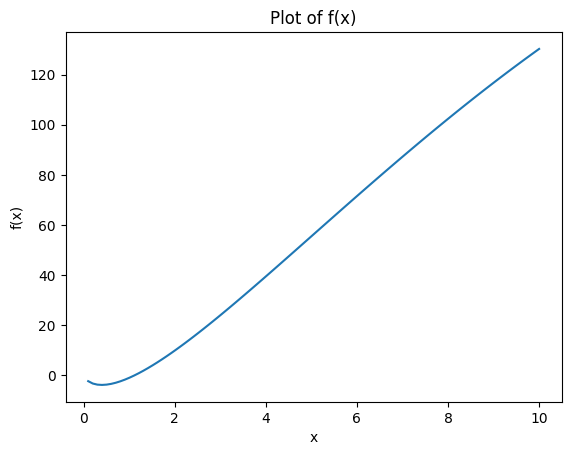

In [75]:
import matplotlib.pyplot as plt
x = torch.linspace(0, 10, 100, requires_grad=True)
y = f(x)
plt.plot(x.detach().numpy(), y.detach().numpy())
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Plot of f(x)')

In [76]:
x = torch.ones(1, requires_grad=True)

# Gradient descent 
for i in range(20): 
    if x.grad is not None:
        x.grad.zero_() # zero the gradients before running the backward pass
    y = f(x) 
    y.backward()
    print("x", x.item(), "f(x)", y.item(), "x.grad", x.grad.item())
    step_size = 0.02 
    with torch.no_grad():
        x -= step_size * x.grad

print("minimum f(x) is at x =", x.item())

x 1.0 f(x) -1.0 x.grad 8.0
x 0.8400000333786011 f(x) -2.170168399810791 x.grad 6.5764665603637695
x 0.7084707021713257 f(x) -2.943650722503662 x.grad 5.136592864990234
x 0.6057388782501221 f(x) -3.403526544570923 x.grad 3.7754592895507812
x 0.5302296876907349 f(x) -3.6451590061187744 x.grad 2.595090627670288
x 0.4783278703689575 f(x) -3.7562689781188965 x.grad 1.6687543392181396
x 0.4449527859687805 f(x) -3.8011531829833984 x.grad 1.0122236013412476
x 0.4247083067893982 f(x) -3.817378282546997 x.grad 0.5870562791824341
x 0.41296717524528503 f(x) -3.822770118713379 x.grad 0.33019453287124634
x 0.40636327862739563 f(x) -3.8244640827178955 x.grad 0.18219608068466187
x 0.4027193486690521 f(x) -3.824977397918701 x.grad 0.09940749406814575
x 0.4007312059402466 f(x) -3.825129270553589 x.grad 0.05389285087585449
x 0.3996533453464508 f(x) -3.825174570083618 x.grad 0.02911585569381714
x 0.3990710377693176 f(x) -3.8251872062683105 x.grad 0.01569974422454834
x 0.39875704050064087 f(x) -3.825191020

In [77]:
# Stochastic Gradient Descent
def noisy_f(x):
    return -x**2 + 10 * x * x.log() + 0.1 * x * torch.randn(1)

x = torch.ones(1, requires_grad=True)
for i in range(1, 21):
    y = noisy_f(x)
    y.backward()

    print("x", x.item(), "f(x)", y.item(), "x.grad", x.grad.item())

    step_size = 0.1 / (i**1.5)
    with torch.no_grad():
        x -= step_size * x.grad

    x.grad.zero_()

print("minimum f(x) is at x =", x.item())

x 1.0 f(x) -0.9899470806121826 x.grad 8.010052680969238
x 0.1989946961402893 f(x) -3.2264366149902344 x.grad -6.412675857543945
x 0.4257170557975769 f(x) -3.9235687255859375 x.grad 0.35790693759918213
x 0.41882914304733276 f(x) -3.846534252166748 x.grad 0.39715349674224854
x 0.41386473178863525 f(x) -3.8890252113342285 x.grad 0.18928217887878418
x 0.41217175126075745 f(x) -3.8465747833251953 x.grad 0.25537222623825073
x 0.41043415665626526 f(x) -3.8589398860931396 x.grad 0.18747347593307495
x 0.4094218909740448 f(x) -3.843747854232788 x.grad 0.20234590768814087
x 0.4085276424884796 f(x) -3.780029296875 x.grad 0.33866065740585327
x 0.4072733521461487 f(x) -3.7981512546539307 x.grad 0.26692283153533936
x 0.406429260969162 f(x) -3.8483924865722656 x.grad 0.12478262186050415
x 0.4060872197151184 f(x) -3.828193187713623 x.grad 0.16689050197601318
x 0.40568575263023376 f(x) -3.856295108795166 x.grad 0.08869296312332153
x 0.4054965376853943 f(x) -3.812159299850464 x.grad 0.1932908296585083
x 

In [78]:
# PyTorch Optimizers 
x = torch.ones(1, requires_grad=True)

optimizer = torch.optim.SGD([x], lr=0.1)

for i in range(20):
    optimizer.zero_grad() # zero the gradient buffers
    y = f(x) 
    y.backward() # compute gradients d(y)/dx
    print("x", x.item(), "f(x)", y.item(), "x.grad", x.grad.item())
    optimizer.step() # Does the update

print("minimum f(x) is at x =", x.item())

x 1.0 f(x) -1.0 x.grad 8.0
x 0.19999998807907104 f(x) -3.258875608444214 x.grad -6.49437952041626
x 0.849437952041626 f(x) -2.1076607704162598 x.grad 6.6693196296691895
x 0.18250596523284912 f(x) -3.1376845836639404 x.grad -7.3747358322143555
x 0.9199795722961426 f(x) -1.613660454750061 x.grad 7.326003074645996
x 0.18737924098968506 f(x) -3.1730024814605713 x.grad -7.120965003967285
x 0.8994757533073425 f(x) -1.7619898319244385 x.grad 7.141616344451904
x 0.1853141188621521 f(x) -3.158186912536621 x.grad -7.227657318115234
x 0.9080798625946045 f(x) -1.7002065181732178 x.grad 7.219611644744873
x 0.18611866235733032 f(x) -3.163985013961792 x.grad -7.185946464538574
x 0.9047133326530457 f(x) -1.7244603633880615 x.grad 7.189201831817627
x 0.18579316139221191 f(x) -3.1616432666778564 x.grad -7.2027974128723145
x 0.9060729146003723 f(x) -1.7146775722503662 x.grad 7.2014994621276855
x 0.18592298030853271 f(x) -3.1625778675079346 x.grad -7.196074485778809
x 0.9055304527282715 f(x) -1.7185828685

##### Loss functions as objective functions

In [79]:
n = 10000; p = 5
dataset_x = torch.randn(n, p) # synthetic dataset 

beta = torch.zeros(p, 1) 
beta[2] = -1.0 
beta[4] = 3.0 

dataset_y = torch.mm(dataset_x, beta) # deterministic function 

def loss(x, y, beta_hat):
    y_hat = torch.mm(x, beta_hat) 
    return ((y_hat - y)**2).mean()

beta_hat = torch.ones((p, 1), requires_grad=True)

optimizer = torch.optim.SGD([beta_hat,], lr = 2e-1)

for i in range(1, 15): 
    mse = loss(dataset_x, dataset_y, beta_hat)
    mse.backward()
    print("mse:", mse.item())
    optimizer.step()
    beta_hat.grad.zero_()

print("estimated beta:", beta_hat.data.numpy().flatten())

mse: 10.90422248840332
mse: 3.9701812267303467
mse: 1.4462839365005493
mse: 0.5271297693252563
mse: 0.1922186017036438
mse: 0.07012617588043213
mse: 0.025595592334866524
mse: 0.009346387349069118
mse: 0.003414362668991089
mse: 0.001247835112735629
mse: 0.0004562221874948591
mse: 0.00016686652088537812
mse: 6.105462671257555e-05
mse: 2.23474398808321e-05
estimated beta: [ 1.1563852e-03  9.3100528e-04 -9.9840945e-01  1.0506510e-03
  2.9984336e+00]


##### Stochastic optimization with minibatches 

In [80]:
n = 10000; p = 5
dataset_x = torch.randn(n, p) # synthetic dataset 

beta = torch.zeros(p, 1) 
beta[2] = -1.0 
beta[4] = 3.0 

dataset_y = torch.mm(dataset_x, beta) # deterministic function 

def loss(x, y, beta_hat):
    y_hat = torch.mm(x, beta_hat) 
    return ((y_hat - y)**2).mean()

beta_hat = torch.ones((p, 1), requires_grad=True)

optimizer = torch.optim.SGD([beta_hat,], lr = 2e-1)

for i in range(1, 15): 
    # sampling indices with replacement is equivalent to sampling a random minibatch of data
    minibatch = torch.randint(n, (128,)) # random indices for a minibatch of size 128
    mse = loss(dataset_x[minibatch], dataset_y[minibatch], beta_hat) # compute loss on the minibatch
    mse.backward()
    print("mse:", mse.item())
    optimizer.step()
    beta_hat.grad.zero_()

print("estimated beta:", beta_hat.data.numpy().flatten())

mse: 11.058670043945312
mse: 4.1233930587768555
mse: 1.64017915725708
mse: 0.3019111752510071
mse: 0.13201606273651123
mse: 0.07986816763877869
mse: 0.028449583798646927
mse: 0.011406045407056808
mse: 0.005017615854740143
mse: 0.0020877178758382797
mse: 0.0005378015921451151
mse: 0.00034098431933671236
mse: 0.0001658297114772722
mse: 7.23569028195925e-05
estimated beta: [ 1.3991972e-03  2.7420886e-03 -9.9684381e-01  6.7706889e-05
  2.9976654e+00]


##### Datasets and DataLoaders

In [81]:
tt_split = int(n * 0.9)
train_ds = TensorDataset(dataset_x[:tt_split], dataset_y[:tt_split])
test_ds = TensorDataset(dataset_x[tt_split:], dataset_y[tt_split:])

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0)
test_dl = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=0)

beta_hat = torch.ones((p, 1), requires_grad=True)
optimizer = torch.optim.SGD([beta_hat,], lr = 2e-1)

for i, (x, y) in enumerate(train_dl):
    mse = loss(x, y, beta_hat)
    mse.backward()
    print("mse:", mse.item())
    optimizer.step()
    beta_hat.grad.zero_()


mse: 11.514408111572266
mse: 3.8000636100769043
mse: 1.3201338052749634
mse: 0.5390560626983643
mse: 0.18996186554431915
mse: 0.06327427923679352
mse: 0.026032771915197372
mse: 0.01165992021560669
mse: 0.003870550310239196
mse: 0.0020310026593506336
mse: 0.0007521849474869668
mse: 0.0001851467532105744
mse: 8.824821998132393e-05
mse: 3.354074578965083e-05
mse: 1.1488545169413555e-05
mse: 5.487912403623341e-06
mse: 1.9882691049133427e-06
mse: 4.326030023094063e-07
mse: 2.120478370670753e-07
mse: 6.800871688028565e-08
mse: 2.1502993163835527e-08
mse: 1.6851563700015504e-08
mse: 5.447020612336928e-09
mse: 1.4340639786780685e-09
mse: 9.178801052556196e-10
mse: 3.2965108420768274e-10
mse: 1.355560941274092e-10
mse: 3.2353536516538384e-11
mse: 1.1361776103280263e-11
mse: 5.360366664430849e-12
mse: 1.994106268998763e-12
mse: 3.6705534445236054e-13
mse: 2.078406891037332e-13
mse: 1.3172709451003684e-13
mse: 1.0350748036458413e-13
mse: 8.785333571736942e-14
mse: 9.319628402337798e-14
mse: 1.061

##### MNIST dataset

In [82]:
train_ds = torchvision.datasets.MNIST(root='.', 
                                      train=True, 
                                      transform=transforms.ToTensor(),
                                      download=True)

test_ds = torchvision.datasets.MNIST(root='.',
                                     train=False, 
                                     transform=transforms.ToTensor())

In [83]:
x, y = train_ds[0]

In [84]:
y

5

In [85]:
x.shape

torch.Size([1, 28, 28])

In [86]:
x[0,6:14,6:14]

tensor([[0.0000, 0.0000, 0.1176, 0.1412, 0.3686, 0.6039, 0.6667, 0.9922],
        [0.0000, 0.1922, 0.9333, 0.9922, 0.9922, 0.9922, 0.9922, 0.9922],
        [0.0000, 0.0706, 0.8588, 0.9922, 0.9922, 0.9922, 0.9922, 0.9922],
        [0.0000, 0.0000, 0.3137, 0.6118, 0.4196, 0.9922, 0.9922, 0.8039],
        [0.0000, 0.0000, 0.0000, 0.0549, 0.0039, 0.6039, 0.9922, 0.3529],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5451, 0.9922, 0.7451],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0431, 0.7451, 0.9922],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1373, 0.9451]])

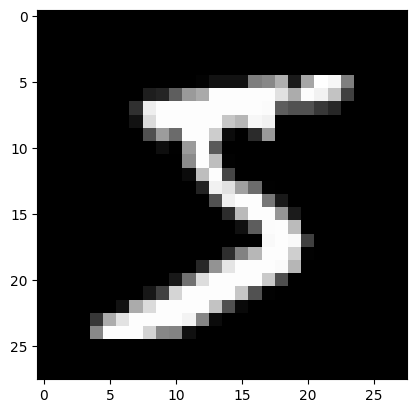

In [87]:
plt.imshow(x[0], cmap='gray')

##### Reporting test set loss

In [88]:
beta_hat = torch.ones((p, 1), requires_grad=True)
optimizer = torch.optim.SGD([beta_hat,], lr = 2e-1)

for epoch in range(5): 
    train_mse = 0.0
    for i, (x, y) in enumerate(train_dl): 
        mse = loss(x, y, beta_hat) 
        mse.backward()
        print("epoch:", epoch, "batch:", i, "mse:", mse.item())
        optimizer.step()
        beta_hat.grad.zero_()
        train_mse += mse.item()

    test_mse = 0.0
    for i, (x, y) in enumerate(test_dl):
        mse = loss(x, y, beta_hat) 
        test_mse += mse.item()
    
    train_mse /= len(train_dl)
    test_mse /= len(test_dl)

    print("train mse:", train_mse, "test mse:", test_mse)

epoch: 0 batch: 0 mse: 11.12732982635498
epoch: 0 batch: 1 mse: 3.239616632461548
epoch: 0 batch: 2 mse: 2.183262586593628
epoch: 0 batch: 3 mse: 0.6035799980163574
epoch: 0 batch: 4 mse: 0.16813772916793823
epoch: 0 batch: 5 mse: 0.07588125765323639
epoch: 0 batch: 6 mse: 0.021564271301031113
epoch: 0 batch: 7 mse: 0.008776552975177765
epoch: 0 batch: 8 mse: 0.003756128018721938
epoch: 0 batch: 9 mse: 0.0006501617026515305
epoch: 0 batch: 10 mse: 0.00021921154984738678
epoch: 0 batch: 11 mse: 0.00010040104098152369
epoch: 0 batch: 12 mse: 4.629486284102313e-05
epoch: 0 batch: 13 mse: 2.219240923295729e-05
epoch: 0 batch: 14 mse: 5.940996288700262e-06
epoch: 0 batch: 15 mse: 2.395282308498281e-06
epoch: 0 batch: 16 mse: 5.14240014126699e-07
epoch: 0 batch: 17 mse: 2.6954302256854135e-07
epoch: 0 batch: 18 mse: 5.094921817772047e-08
epoch: 0 batch: 19 mse: 1.5099637096227525e-08
epoch: 0 batch: 20 mse: 7.062816109737469e-09
epoch: 0 batch: 21 mse: 2.154652012364977e-09
epoch: 0 batch: 2

##### Refactoring

In [89]:
beta_hat = torch.ones((p, 1), requires_grad=True)
optimizer = torch.optim.SGD([beta_hat,], lr = 2e-1)

def train_loop(): 
    train_mse = 0.0
    for i, (x, y) in enumerate(train_dl): 
        mse = loss(x, y, beta_hat) 
        mse.backward()
        print("batch:", i, "mse:", mse.item())
        optimizer.step()
        beta_hat.grad.zero_()
        train_mse += mse.item()
    
    return train_mse / len(train_dl)

def test_loop():
    test_mse = 0.0
    for i, (x, y) in enumerate(test_dl):
        mse = loss(x, y, beta_hat) 
        test_mse += mse.item()
    
    return test_mse / len(test_dl)

for epoch in range(5):
    train_mse = train_loop()
    test_mse = test_loop()
    print("epoch:", epoch, "train mse:", train_mse, "test mse:", test_mse)

batch: 0 mse: 9.988460540771484
batch: 1 mse: 4.708291053771973
batch: 2 mse: 1.3412270545959473
batch: 3 mse: 0.5602600574493408
batch: 4 mse: 0.2713772654533386
batch: 5 mse: 0.1244119182229042
batch: 6 mse: 0.04710816219449043
batch: 7 mse: 0.028656810522079468
batch: 8 mse: 0.009176315739750862
batch: 9 mse: 0.0023943521082401276
batch: 10 mse: 0.0009175997693091631
batch: 11 mse: 0.0005121526191942394
batch: 12 mse: 9.633142326492816e-05
batch: 13 mse: 3.772739364649169e-05
batch: 14 mse: 1.020228592096828e-05
batch: 15 mse: 2.876436155929696e-06
batch: 16 mse: 1.2889219078715541e-06
batch: 17 mse: 7.343081165345211e-07
batch: 18 mse: 2.9582392357951903e-07
batch: 19 mse: 8.707925047701792e-08
batch: 20 mse: 2.1807938566098528e-08
batch: 21 mse: 1.3603795423478005e-08
batch: 22 mse: 4.812703569001542e-09
batch: 23 mse: 1.109981662139603e-09
batch: 24 mse: 4.840945977413469e-10
batch: 25 mse: 2.3188126418993704e-10
batch: 26 mse: 1.2928219605967683e-10
batch: 27 mse: 3.342662258098

##### (Built-in) Linear Modules

In [90]:
class LinearRegression(nn.Module): 
    def __init__(self, p):
        super(LinearRegression, self).__init__()
        self.beta_hat = nn.Parameter(torch.ones(p, 1)) # model parameters to be learned

    def forward(self, x):
        yhat = torch.mm(x, self.beta_hat)
        return yhat

lr = LinearRegression(p) 
# lr = nn.Linear(p, 1, bias=False) # alternative way to define a linear regression model without bias term
optimizer = torch.optim.SGD(lr.parameters(), lr = 2e-1)
getmse = torch.nn.MSELoss() # mean squared error loss function

def train_loop(): 
    train_mse = 0.0
    for i, (x, y) in enumerate(train_dl): 
        yhat = lr(x) # forward pass
        mse = getmse(yhat, y) # compute loss
        mse.backward() # compute gradients
        print("batch:", i, "mse:", mse.item())
        optimizer.step() # update parameters
        optimizer.zero_grad() # zero the gradients after updating
        train_mse += mse.item()
    
    return train_mse / len(train_dl)

##### Nonlinear data fit by a linear model 

In [91]:
n = 10000; p = 5
dataset_x = torch.randn(n, p) # synthetic dataset
dataset_y = (dataset_x ** 4).sum(1)

##### Nonlinear data fit by a linear model 

In [92]:
train_mse_history = []
test_mse_history = []

for epoch in range(1000): 
    train_mse = train_loop()
    test_mse = test_loop()
    train_mse_history.append(train_mse)
    test_mse_history.append(test_mse)
    print("epoch:", epoch, "train mse:", train_mse, "test mse:", test_mse)

    if epoch >= 4 and test_mse < 1e-3:
        print("stopping early: test mse reached threshold")
        break


batch: 0 mse: 9.446149826049805
batch: 1 mse: 5.476281642913818
batch: 2 mse: 1.3636213541030884
batch: 3 mse: 0.5865466594696045
batch: 4 mse: 0.15168535709381104
batch: 5 mse: 0.0826609805226326
batch: 6 mse: 0.028710676357150078
batch: 7 mse: 0.01367771252989769
batch: 8 mse: 0.00577226048335433
batch: 9 mse: 0.00276808999478817


batch: 10 mse: 0.0007013338035903871
batch: 11 mse: 0.0002039392857113853
batch: 12 mse: 8.374375465791672e-05
batch: 13 mse: 4.16390503232833e-05
batch: 14 mse: 1.3206367839302402e-05
batch: 15 mse: 4.2924539229716174e-06
batch: 16 mse: 1.8798307337419828e-06
batch: 17 mse: 6.507681860057346e-07
batch: 18 mse: 3.1218968388202484e-07
batch: 19 mse: 1.1170146763106459e-07
batch: 20 mse: 5.108454459445966e-08
batch: 21 mse: 2.6940265129837826e-08
batch: 22 mse: 9.48979650416959e-09
batch: 23 mse: 3.6011649218181674e-09
batch: 24 mse: 2.0914281417816483e-09
batch: 25 mse: 4.869835645848752e-10
batch: 26 mse: 2.6153240684223533e-10
batch: 27 mse: 4.5766258838231266e-11
batch: 28 mse: 1.982889200058402e-11
batch: 29 mse: 8.070173002083791e-12
batch: 30 mse: 4.632518327274404e-12
batch: 31 mse: 1.4932430292269316e-12
batch: 32 mse: 5.151504223199765e-13
batch: 33 mse: 2.4668635190128185e-13
batch: 34 mse: 1.0695958008177797e-13
batch: 35 mse: 1.0810102812897071e-13
batch: 36 mse: 1.161865742

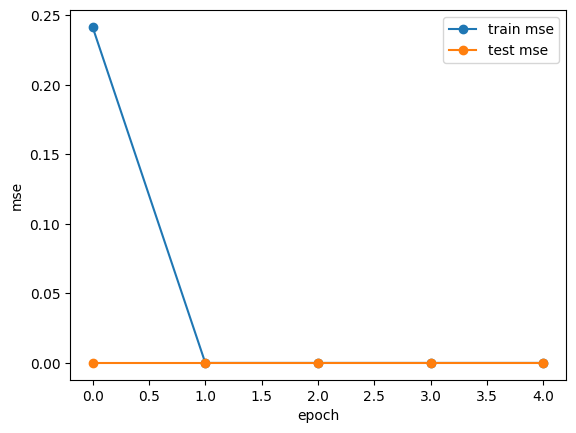

In [93]:
plt.plot(train_mse_history, marker="o", label="train mse")
plt.plot(test_mse_history, marker="o", label="test mse")
plt.xlabel("epoch")
plt.ylabel("mse")
plt.legend()
plt.show()


##### Nonlienar data fit by a nonlinear model 

In [94]:
hidden_dim = 32
model = nn.Sequential(
    nn.Linear(p, hidden_dim), 
    nn.ReLU(), 
    nn.Linear(hidden_dim, 1)
)

epoch: 0 train mse: 359.6626464413925 test mse: 195.79571628570557
epoch: 1 train mse: 212.39638981349032 test mse: 173.63943004608154
epoch: 2 train mse: 176.02145466334383 test mse: 134.044038772583
epoch: 3 train mse: 156.16533510449906 test mse: 178.60529327392578
epoch: 4 train mse: 151.3738784790039 test mse: 126.83557033538818
epoch: 5 train mse: 144.22970967897228 test mse: 124.6750316619873
epoch: 6 train mse: 133.84118077452754 test mse: 141.82977390289307
epoch: 7 train mse: 130.23240242541675 test mse: 119.4826774597168
epoch: 8 train mse: 119.25461191526601 test mse: 93.954580783844
epoch: 9 train mse: 105.26881978209589 test mse: 89.42793893814087
epoch: 10 train mse: 97.11080309370874 test mse: 77.7372214794159
epoch: 11 train mse: 84.57718134597994 test mse: 69.50004386901855
epoch: 12 train mse: 75.90484096634556 test mse: 71.88001418113708
epoch: 13 train mse: 67.87679850887245 test mse: 51.99958872795105
epoch: 14 train mse: 61.270117732840525 test mse: 46.7641162872

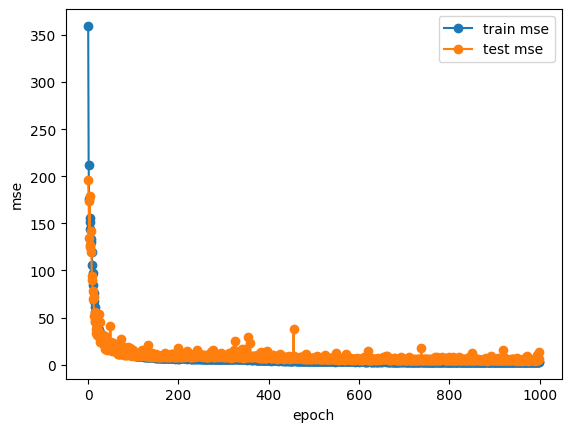

In [95]:
tt_split = int(n * 0.9)
train_ds = TensorDataset(dataset_x[:tt_split], dataset_y[:tt_split].unsqueeze(1))
test_ds = TensorDataset(dataset_x[tt_split:], dataset_y[tt_split:].unsqueeze(1))

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0)
test_dl = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=0)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2) # nonlinear (neural network) model

def train_loop():
    model.train()
    train_mse = 0.0
    for x_batch, y_batch in train_dl:
        optimizer.zero_grad()
        y_hat = model(x_batch)
        mse = criterion(y_hat, y_batch)
        mse.backward()
        optimizer.step()
        train_mse += mse.item()
    return train_mse / len(train_dl)


def test_loop():
    model.eval()
    test_mse = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_dl:
            y_hat = model(x_batch)
            mse = criterion(y_hat, y_batch)
            test_mse += mse.item()
    return test_mse / len(test_dl)

train_mse_history = []
test_mse_history = []

for epoch in range(1000):
    train_mse = train_loop()
    test_mse = test_loop()
    train_mse_history.append(train_mse)
    test_mse_history.append(test_mse)
    print("epoch:", epoch, "train mse:", train_mse, "test mse:", test_mse)

    if epoch >= 4 and test_mse < 1e-3:
        print("stopping early: test mse reached threshold")
        break

plt.plot(train_mse_history, marker="o", label="train mse")
plt.plot(test_mse_history, marker="o", label="test mse")
plt.xlabel("epoch")
plt.ylabel("mse")
plt.legend()
plt.show()
